In [1]:
#%load_ext autoreload 
#%autoreload 2

from networks.BP_network import *
from networks.DFC_network import *
from src.dataloaders import *
from src.trainers import Trainer, TrainerDFCL, TrainerCL, TrainerCL_DFC, TrainerCL_DFC2
from src.utils import *
from src.utils import *

/cluster/raid/home/sschwartz/.conda/envs/DFC_project/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
config = {
        "layers": [784,200,200,10],
        "num_classes": 10,
        "lr": 1e-4, 
        "lr_fb": 1e-4, 
        "batch_size": 100,
        "batch_size_gen": 30000,
        "epochs": 20,
        "mode": "di",
        "num_workers": 0,
        "loss_fn": "ce",
        "optimizer": "Adam",
        "scheduler": "CosineAnnealingLR",
        "activation_fun": "Tanh",
        "device": "cuda",
        "output_dir": "./outputs_cl/",
        "seed": 1337,
        "taus": [0.02, 0.02, 0.02, 0.016, 0.01],
        "target_lr": 1,#1e-2,       # Updated to optimal value
        "alpha_di": 0.0017,        # 1/tau for tau=0.2
        "dt_di": 0.02,         # Time step
        "time_constant_ratio": 0.2,  # tau
        "tmax_di":2,
        "k_p": 2.0,             # Optimal for G=1, tau=0.2
        "eps": 1e-4,
        "save": True,
        "flatten_imgs": "default",
        "num_tasks": 5,
        "classes_per_task": 2,
        "setting": "classIL5task",
        "first_task_only": False,
        "thresholds": [0.1,0.1,0.001],
}

config = dotdict(config)

In [3]:
tasks_dataloaders = ClassILMNIST5Task(config=config).get_all_tasks_dataloaders()

In [ ]:
# Train model
model = DFCL_network_multilayer(config=config)

trainer = TrainerCL_DFC(model, tasks_dataloaders, config)
trainer.train()

[DFCL] Feedback connections initialized.
Training:
 - layers: [784, 200, 200, 10]
 - num_classes: 10
 - lr: 0.0001
 - lr_fb: 0.0001
 - batch_size: 100
 - batch_size_gen: 30000
 - epochs: 20
 - mode: di
 - num_workers: 0
 - loss_fn: ce
 - optimizer: Adam
 - scheduler: CosineAnnealingLR
 - activation_fun: Tanh
 - device: cuda
 - output_dir: ./outputs_cl/
 - seed: 1337
 - taus: [0.02, 0.02, 0.02, 0.016, 0.01]
 - target_lr: 1
 - alpha_di: 0.0017
 - dt_di: 0.02
 - time_constant_ratio: 0.2
 - tmax_di: 2
 - k_p: 2.0
 - eps: 0.0001
 - save: True
 - flatten_imgs: default
 - num_tasks: 5
 - classes_per_task: 2
 - setting: classIL5task
 - first_task_only: False
 - thresholds: [0.1, 0.1, 0.001]
 - in_channels: 1
 - model: DFCL_network

[TrainerDFCL] Created optimizers: feedforward, 1× feedback.
Starting Task 1/5


				Epoch: 001, Train loss: 1.5888 & test losses: T0: 0.7689 & accuracy: T0: 96.26, Full: 96.26


				Epoch: 002, Train loss: 0.3619 & test losses: T0: 0.1407 & accuracy: T0: 99.72, Full: 99.72


				Epoch: 003, Train loss: 0.0922 & test losses: T0: 0.0552 & accuracy: T0: 99.86, Full: 99.86


				Epoch: 004, Train loss: 0.0456 & test losses: T0: 0.0318 & accuracy: T0: 99.91, Full: 99.91


...

				Epoch: 019, Train loss: 0.0080 & test losses: T0: 1.9094, T1: 2.3646, T2: 1.2917, T3: 0.3806, T4: 0.0879 & accuracy: T0: 53.85, T1: 49.46, T2: 67.61, T3: 88.92, T4: 97.43, Full: 71.14


				Epoch: 020, Train loss: 0.0071 & test losses: T0: 1.9583, T1: 2.3911, T2: 1.3326, T3: 0.3933, T4: 0.0830 & accuracy: T0: 53.10, T1: 49.46, T2: 67.45, T3: 88.52, T4: 97.48, Full: 70.88
Testing on all seen classes up to Task 5


Testing  epoch 000/20:  64%|██████▍   | 64/100 [00:00<00:00, 634.01batch/s]

Seen Classes - Loss: 1.2467, Accuracy: 70.8800


Testing  epoch 000/20: 100%|██████████| 100/100 [00:10<00:00, 634.01batch/s]

In [12]:
@torch.no_grad()
def generate_samples(model, target_activity, init_input=None, batch_size=10, tmax=500, pixel_std=None, pixel_mean=None, thresholds=[0.1, 0.1, 0.001]):
    # === Setup ===
    model.targets = target_activity
    model.bzs = target_activity.shape[0]

    # Initialize input (random if none provided)
    if init_input is None:
        init_input_scaled = (
            torch.clamp(torch.randn(batch_size, 28 * 28, device=model.device)
            * pixel_std.flatten().to(model.device)
            + pixel_mean.flatten().to(model.device), -0.4242, 2.8215)
        )
        model.input = init_input_scaled
    else:
        model.input = init_input.to(model.device)

    layer_out_dims = [layer.weights.shape[0] for layer in model.layers]

    v_fb_current = [torch.zeros((model.bzs, lod), device=model.input.device) for lod in layer_out_dims]
    v_ff_current = [torch.zeros((model.bzs, lod), device=model.input.device) for lod in layer_out_dims]
    v_current = [torch.zeros((model.bzs, lod), device=model.input.device) for lod in layer_out_dims]
    r_current = [torch.zeros((model.bzs, lod), device=model.input.device) for lod in layer_out_dims]

    # One PI controller per layer
    u_current = [torch.zeros((model.bzs, lod), device=model.input.device) for lod in layer_out_dims]
    u_int_current = [torch.zeros((model.bzs, lod), device=model.input.device) for lod in layer_out_dims]

    # Forward init
    r_prev = model.input
    for i, layer in enumerate(model.layers):
        v_ff_current[i] = r_prev.mm(layer.weights.t()) + layer.bias.unsqueeze(0)
        v_current[i] = v_ff_current[i].clone()
        r_current[i] = layer.activation_fn(v_ff_current[i])
        r_prev = r_current[i]

    _ = model(model.input)

    diffs = []
    diffs2 = []
    diffs3 = []
    video = [model.input[12].clone()]
    rs_hist = [model.layers[-1].r[12].clone()]

    tau = model.dt / model.time_constant_ratio
    n_layers = len(model.layers)

    # Simulate tmax timesteps
    for t_step in range(tmax - 1):
        # store updated controllers for this step
        u_next = [u.clone() for u in u_current]
        u_int_next = [u.clone() for u in u_int_current]

        # convergence mask for every controller
        converged_mask_per_layer = [None] * n_layers

        # Iterate from output layer down to first hidden layer
        for i in reversed(range(n_layers)):
            layer = model.layers[i]

            # --- 1) Update controller for this layer ---
            if i != n_layers - 1:
                error_i = model._compute_error_mse(
                    layer.activation_fn(v_ff_current[i]),
                    r_current[i]
                )
            else:
                error_i = model._compute_error(r_current[i], model.targets)

            u_int_next[i] = u_int_current[i] + model.dt * (error_i - model.alpha * u_current[i])
            u_next[i] = u_int_next[i] + model.k_p * error_i 

            converged_mask_per_layer[i] = torch.abs(error_i).mean(dim=1) < thresholds[i]

            # --- 2) Update activity for this layer ---
            r_prev = r_current[i - 1] if i != 0 else model.input

            # Basal update
            v_ff_current[i] += (
                r_prev.mm(layer.weights.t()) + layer.bias.unsqueeze(0) - v_ff_current[i]
            )
            v_ff_current[i] = v_ff_current[i].clone().detach()

            # Apical / soma update
            if i != n_layers - 1:
                v_fb_current[i] = (model.feedback_layers[i + 1](u_next[i + 1])) *  layer.activation_derivative(v_ff_current[i])
                v_current[i] += tau * (
                    v_fb_current[i] * (~converged_mask_per_layer[i + 1].unsqueeze(1))
                    + v_ff_current[i] - v_current[i]
                    - u_next[i] * (~converged_mask_per_layer[i].unsqueeze(1))
                )
            else:
                v_current[i] += tau * (v_ff_current[i] - v_current[i])

            r_current[i] = layer.activation_fn(v_current[i])

            layer.v_ff = v_current[i]
            layer.r = r_current[i]

        # Commit controller updates after full downward sweep
        u_int_current = u_int_next
        u_current = u_next

        # Input update
        grad_input = model.feedback_layers[0](model.layers[0].activation_fn(v_ff_current[0])) 
        grad_input += model.feedback_layers[0](u_next[0]) 

        model.input += tau * (grad_input - torch.abs(model.input))
        model.input = torch.clamp(model.input, -0.4242, 2.8215)

        video.append(model.input[12].clone())
        rs_hist.append(model.layers[-1].r[12].clone())

        diff = torch.abs(
            r_current[0] - model.layers[0].activation_fn(v_ff_current[0])
        ).mean().detach().cpu().numpy()
        diffs.append(diff)

        if len(model.layers) > 1:
            diff2 = torch.abs(
                r_current[1] - model.layers[1].activation_fn(v_ff_current[1])
            ).mean().detach().cpu().numpy()
            diffs2.append(diff2)
        
        if len(model.layers) > 2:
            diff3 = torch.abs(
                r_current[2] - model.layers[2].activation_fn(v_ff_current[2])
            ).mean().detach().cpu().numpy()
            diffs3.append(diff3)

    # === Collect steady-state representations ===
    rs = [model.input]
    for i, layer in enumerate(model.layers):
        layer.r = r_current[i]
        layer.r_ff = layer.activation_fn(v_ff_current[i])
        layer.r_prev = rs[i]
        rs.append(r_current[i])

    print(converged_mask_per_layer[-1].sum())

    generated_inputs = model.input

    if len(diffs) > 0:
        print(diffs[-1])
    if len(diffs2) > 0:
        print(diffs2[-1])
    if len(diffs3) > 0:
        print(diffs3[-1])

    return generated_inputs, rs, video, diffs, diffs2, diffs3, rs_hist

In [21]:
batch_size = 100

Xs = []
Ys = []
Y_preds = []

for batch in tasks_dataloaders[1][0]:
    x = batch[0].to(model.device)
    y = batch[1].to(model.device)

    ypred = model(x)
    B, K = ypred.shape   # use model output size

    # true class indices
    top1 = y.argmax(dim=1)   # (B,)

    # sample a random class different from top1
    rand = torch.randint(0, 2, (B,), device=model.device)
    rand = rand + (rand >= top1).long()


    Y_preds.append(rand)
    Xs.append(batch[0])
    Ys.append(batch[1])

    if batch_size == 100:
        break

X = torch.cat(Xs, dim=0)
Y = torch.cat(Ys, dim=0)
Y_label = torch.argmax(Y, dim=1)
target2 = torch.cat(Y_preds,dim=0)
target2 = F.one_hot(torch.tensor(target2), num_classes=10)

print("random targets generated ...")

generated_input2, rs, video2, diffs_2, diffs2_2, diffs3_2, rs_hist = generate_samples(
    model,
    target2,
    batch_size=batch_size,
    tmax=5000,
    init_input=X.to(model.device),
    thresholds=[0.001, 0.001, 0.001, 0.1],
)

print((target2.argmax(dim=1) == rs[-1].argmax(dim=1)).sum())
print((target2.argmax(dim=1) == model(generated_input2).argmax(dim=1)).sum())

random targets generated ...
tensor(91, device='cuda:0')
0.005640035
0.032793846
tensor(100, device='cuda:0')
tensor(100, device='cuda:0')


In [ ]:
imgs = generated_input2.detach().cpu()
n_cols=10

# Normalize to [0, 1] for display
#imgs = (imgs - imgs.min()) / (imgs.max() - imgs.min() + 1e-8)

# Try to infer image dimensions (e.g. 28x28 for MNIST)
img_size = int(imgs.shape[1] ** 0.5)
imgs = imgs.view(-1, img_size, img_size)

n_samples = imgs.shape[0]
n_rows = (n_samples + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 1.5, n_rows * 1.5))
for i in range(n_samples):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.imshow(imgs[i], cmap="gray", vmin=-0.4242, vmax=2.8215)
    #plt.imshow(imgs[i], cmap="gray", vmin=0, vmax=1)
    #plt.imshow(imgs[i], cmap="gray")
    plt.axis("off")
    if i ==100:
        break

plt.tight_layout()

plt.show()


In [ ]:
from matplotlib import animation


fig = plt.figure()
im = plt.imshow(video2[0].cpu().reshape(28,28),cmap="grey",  vmin=-0.4242, vmax=2.8215)
plt.axis("off")

def update(i):

    im.set_array(video2[i].cpu().reshape(28,28))
    return [im]

ani = animation.FuncAnimation(fig, update, frames=100, interval=50)


In [31]:

ani.save('morphing_animations/diagnostic.gif', writer='pillow', fps=5)

Animation.save using <class 'matplotlib.animation.PillowWriter'>


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Darker colors
colors = {
    "layer1": "#1f77b4",  # dark blue
    "layer2": "#4b0082",  # indigo (darker purple)
    "layer3": "#8b0000",  # dark red
}

# Dashed lines (second dataset)
plt.plot(diffs_2,  alpha=0.8, color=colors["layer1"], linestyle="--")
plt.plot(diffs2_2, alpha=0.8, color=colors["layer2"], linestyle="--")
plt.plot(diffs3_2, alpha=0.8, color=colors["layer3"], linestyle="--")

plt.ylim([0, 0.1])
plt.xlabel("t")
plt.ylabel("MAE")

# Custom legend
legend_elements = [
    Line2D([0], [0], color=colors["layer1"], lw=2, label="Layer 1"),
    Line2D([0], [0], color=colors["layer2"], lw=2, label="Layer 2"),
    Line2D([0], [0], color=colors["layer3"], lw=2, label="Layer 3"),
    Line2D([0], [0], color="black", lw=2, linestyle="-", label="Random init"),
    Line2D([0], [0], color="black", lw=2, linestyle="--", label="Contrastive init"),
]

plt.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

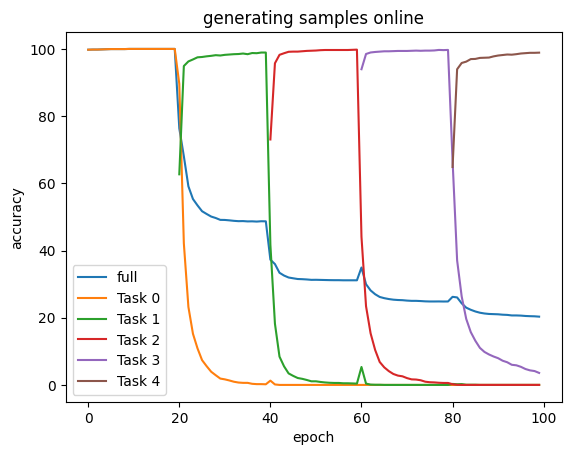

In [ ]:
plt.plot(trainer.accuracies_full, label="full")
for i in range(len(trainer.accuracies_tasks)):
    plt.plot(range(i*20,100),trainer.accuracies_tasks[i], label=f"Task {i}")
plt.title("generating samples online")
plt.ylabel("accuracy")
plt.xlabel("epoch")
plt.legend()
plt.show()



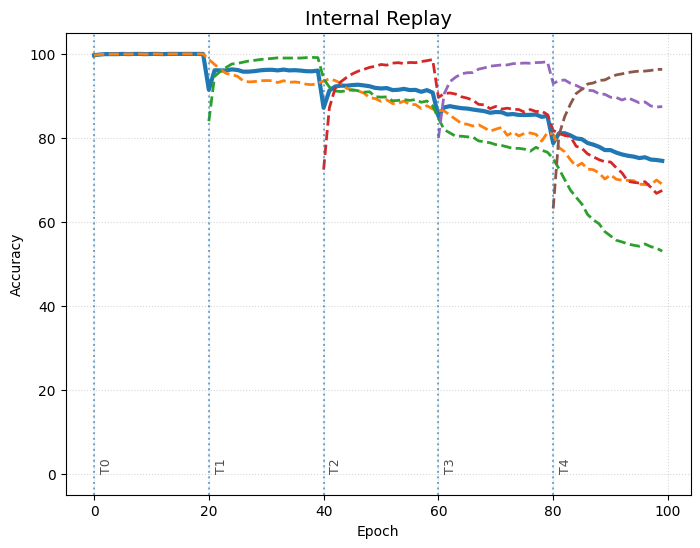

In [12]:
plt.figure(figsize=(10, 6))

# ... your plotting code ...

# Plot full accuracy
plt.plot(
    trainer.accuracies_full,
    label="Overall Accuracy",
    linewidth=3
)

# Plot task accuracies
for i, acc in enumerate(trainer.accuracies_tasks):
    epochs = range(i * 20, i * 20 + len(acc))
    plt.plot(
        epochs,
        acc,
        linestyle="--",
        linewidth=2,
        label=f"Task {i}"
    )

# --- Mark task boundaries ---
num_tasks = len(trainer.accuracies_tasks)
for i in range(num_tasks):
    x = i * 20
    plt.axvline(
        x=x,
        linestyle=":",
        alpha=0.6,
        linewidth=1.5
    )
    plt.text(
        x + 1,
        0.02,  # adjust depending on your y-range
        f"T{i}",
        rotation=90,
        verticalalignment='bottom',
        fontsize=9,
        alpha=0.7
    )

# Labels and styling
plt.title("Internal Replay", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim([-5,105])

plt.grid(True, linestyle=":", alpha=0.5)

"""plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)"""

# Reserve space on the right for legend
plt.subplots_adjust(right=0.75)


#plt.tight_layout()
plt.show()

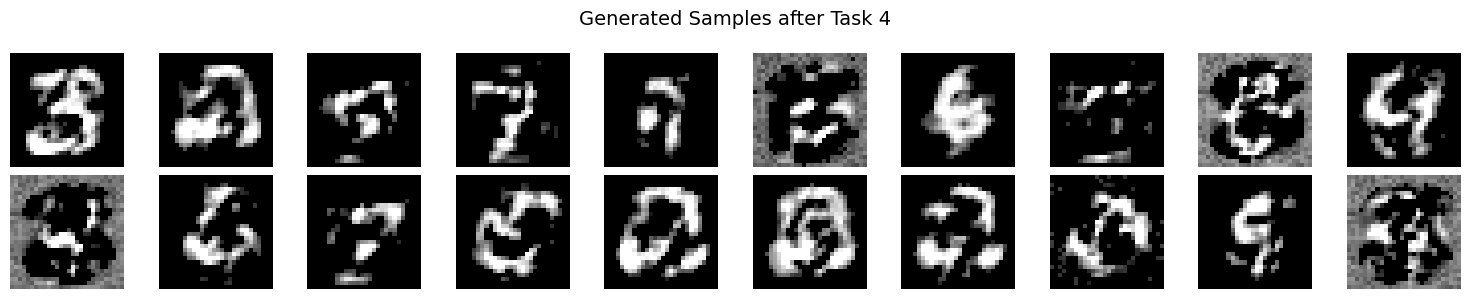

In [5]:

plot_generated_inputs(trainer.gen_samples[3][:20], n_cols=10, title="Generated Samples after Task 4", save=False, filename="Samples_BP_100_epochs.png")

In [8]:
import joblib
from tqdm import tqdm


# --- 1. Load MNIST ---
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # flatten 28x28 -> 784
])
mnist_train = datasets.MNIST(root="./data", train=True, transform=transform, download=True)

# Convert entire dataset to tensors
X = torch.stack([mnist_train[i][0] for i in tqdm(range(len(mnist_train)), desc="Loading MNIST")])
y = torch.tensor([mnist_train[i][1] for i in range(len(mnist_train))])

# Load UMAP model
reducer = joblib.load("umap_model.pkl")

# Load embedding
embedding = np.load("mnist_umap_embedding.npy")
































































Loading MNIST: 100%|██████████| 60000/60000 [00:06<00:00, 9244.46it/s]


In [ ]:
x_final = generated_input2.clone().detach().cpu()
sm = torch.nn.Softmax(dim=1)
y_hat = target2
y_labels = torch.argmax(y_hat, dim=1)

embedding_gen = reducer.transform(x_final.numpy())
print("Generated embedding shape:", embedding_gen.shape)

# --- Plot ---
fig = plt.figure(figsize=(9, 9))

# Main plot axis (fixed size)
ax = fig.add_axes([0.1, 0.1, 0.75, 0.8])

# Reserved space for colorbar (always exists!)
cax = fig.add_axes([0.88, 0.1, 0.03, 0.8])

# Plot generated samples
scatter_gen = ax.scatter(
    embedding_gen[:, 0], embedding_gen[:, 1],
    c=y_labels.cpu(), cmap="Spectral", s=1, alpha=0.8, label="Generated"
)

"""scatter_mnist = ax.scatter(
    embedding[:, 0], embedding[:, 1],
    c=y.cpu(), cmap="Spectral", s=1, alpha=0.8, label="MNIST"
)"""


# Remove tick labels
#ax.set_xticklabels([])
#ax.set_yticklabels([])
#ax.grid(True, alpha=0.3)

# Toggle this flag
use_colorbar = True

if use_colorbar:
    cbar = plt.colorbar(
        scatter_gen,
        cax=cax,
        boundaries=np.arange(11) - 0.5,
        ticks=np.arange(10)
    )
    cbar.set_label("Predicted Label")
else:
    # Keep layout identical, just hide colorbar axis
    cax.axis("off")

plt.show()

Generated embedding shape: (12089, 2)


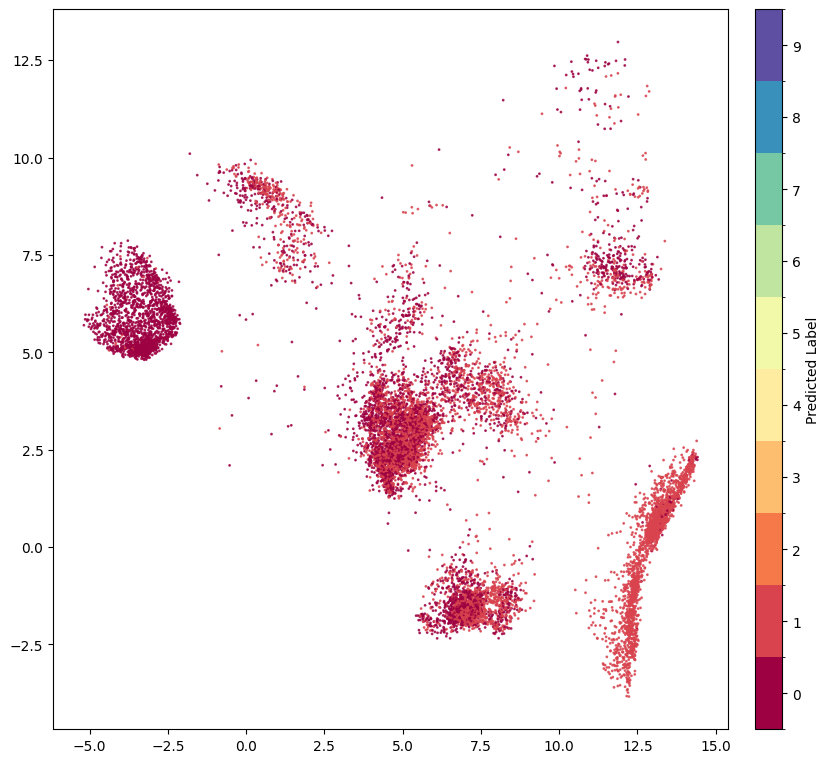

Generated embedding shape: (22526, 2)


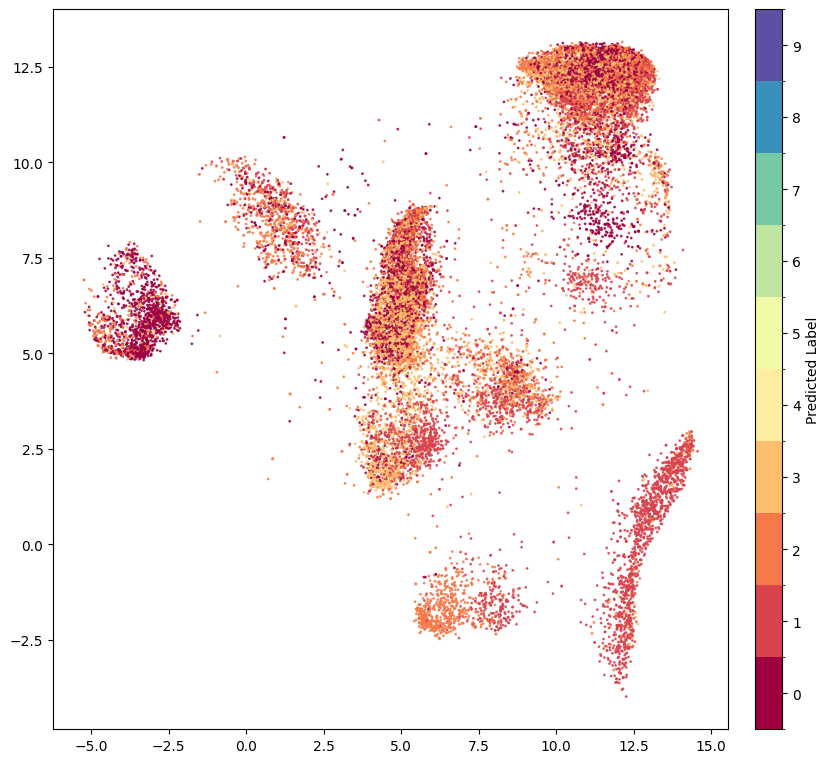

Generated embedding shape: (36549, 2)


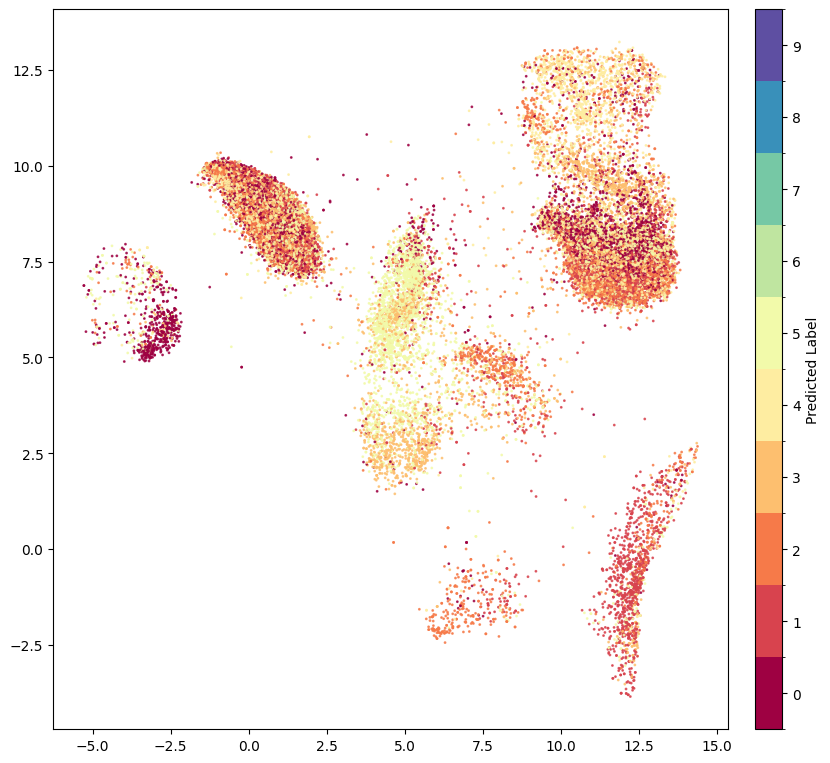

In [ ]:
import matplotlib as mpl

for i in range(4):
    x_final = trainer.gen_samples[i].clone().detach().cpu()
    sm = torch.nn.Softmax(dim=1)
    y_hat = trainer.gen_targets[i]
    y_labels = torch.argmax(y_hat, dim=1)

    embedding_gen = reducer.transform(x_final.numpy())
    print("Generated embedding shape:", embedding_gen.shape)

    # --- Plot ---
    fig = plt.figure(figsize=(9, 9))

    # Main plot axis (fixed size)
    ax = fig.add_axes([0.1, 0.1, 0.75, 0.8])

    # Reserved space for colorbar (always exists!)
    cax = fig.add_axes([0.88, 0.1, 0.03, 0.8])

    cmap = plt.get_cmap("Spectral")

    # Fixed normalization for labels 0–9
    norm = mpl.colors.BoundaryNorm(
        boundaries=np.arange(11) - 0.5,
        ncolors=cmap.N
    )


    # Plot generated samples
    scatter_gen = ax.scatter(
        embedding_gen[:, 0], embedding_gen[:, 1],
        c=y_labels.cpu(), cmap=cmap, norm=norm, s=1, alpha=0.8, label="Generated"
    )

    """scatter_mnist = ax.scatter(
        embedding[:, 0], embedding[:, 1],
        c=y.cpu(), cmap="Spectral", s=1, alpha=0.8, label="MNIST"
    )"""


    # Remove tick labels
    #ax.set_xticklabels([])
    #ax.set_yticklabels([])
    #ax.grid(True, alpha=0.3)


    # Toggle this flag
    use_colorbar=True
    if use_colorbar:
        cmap = plt.get_cmap("Spectral")
        
        # Fixed normalization for 10 classes (0–9)
        norm = mpl.colors.BoundaryNorm(
            boundaries=np.arange(11) - 0.5,
            ncolors=cmap.N
        )

        sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])  # required for colorbar

        cbar = plt.colorbar(
            sm,
            cax=cax,
            boundaries=np.arange(11) - 0.5,
            ticks=np.arange(10)
        )
        cbar.set_label("Predicted Label")

    else:
        # Keep layout identical, just hide colorbar axis
        cax.axis("off")

    plt.show()

In [ ]:
def confusion_matrix(model, dataloader, num_classes, device="cuda"):
    model.eval()
    cm = torch.zeros(num_classes, num_classes, dtype=torch.int64)

    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs = inputs.to(device)
            targets = targets.argmax(dim=1).to(device)

            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)

            for t, p in zip(targets.view(-1), preds.view(-1)):
                cm[t.long(), p.long()] += 1

    return cm

In [ ]:
import torch
from torch.utils.data import ConcatDataset, DataLoader

def concat_dataloaders(dataloaders, shuffle=True):
    """
    Concatenate multiple PyTorch DataLoaders into one.

    Args:
        dataloaders (list): list of DataLoader objects
        shuffle (bool): whether to shuffle the combined dataset

    Returns:
        DataLoader: new combined DataLoader
    """

    if len(dataloaders) == 0:
        raise ValueError("You must provide at least one DataLoader")

    # Extract datasets
    datasets = [dl.dataset for dl in dataloaders]

    # Combine datasets
    combined_dataset = ConcatDataset(datasets)

    # Use settings from the first dataloader (assumes consistency)
    ref_dl = dataloaders[0]

    g = torch.Generator(device="cuda")

    combined_loader = DataLoader(
        combined_dataset,
        batch_size=ref_dl.batch_size,
        shuffle=shuffle,
        num_workers=ref_dl.num_workers,
        pin_memory=getattr(ref_dl, "pin_memory", False),
        generator=g
    )

    return combined_loader

In [ ]:
combined_loader = concat_dataloaders(
    [tasks_dataloaders[i][0] for i in range(5)]
)

In [ ]:
with torch.device("cuda"):
    cm = confusion_matrix(model, combined_loader, num_classes=10, device="cuda")
    print(cm)

tensor([[1405,    0,   61,   10,    6, 1023,  239,   37, 2065, 1077],
        [   0, 2024,   17,    7,   18,   26,   18,   36, 4490,  106],
        [   3,    7, 2917,   42,   96,   25,  413,  134, 2162,  159],
        [   1,    1,   28, 1930,    5,  361,   56,  108, 2801,  840],
        [   0,    1,    4,    1, 3248,    1,   73,   14,  178, 2322],
        [   1,    0,    4,   24,   27, 3083,  104,   34, 1672,  472],
        [   2,    0,    4,    3,   18,   55, 5501,    1,  310,   24],
        [   0,    0,    7,    4,   16,    2,    0, 5451,   93,  692],
        [   0,    0,    0,    0,    0,    0,    4,    2, 5831,   14],
        [   0,    0,    0,    0,    0,    0,    0,    7,   28, 5914]],
       device='cuda:0')


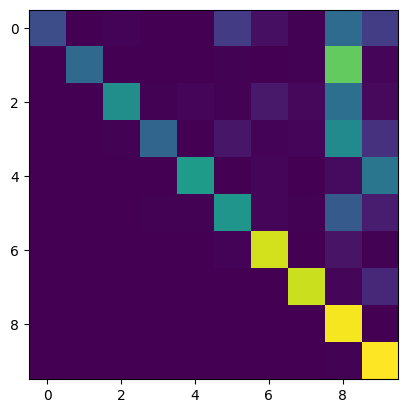

In [ ]:
plt.imshow(cm.cpu().numpy())
plt.show()

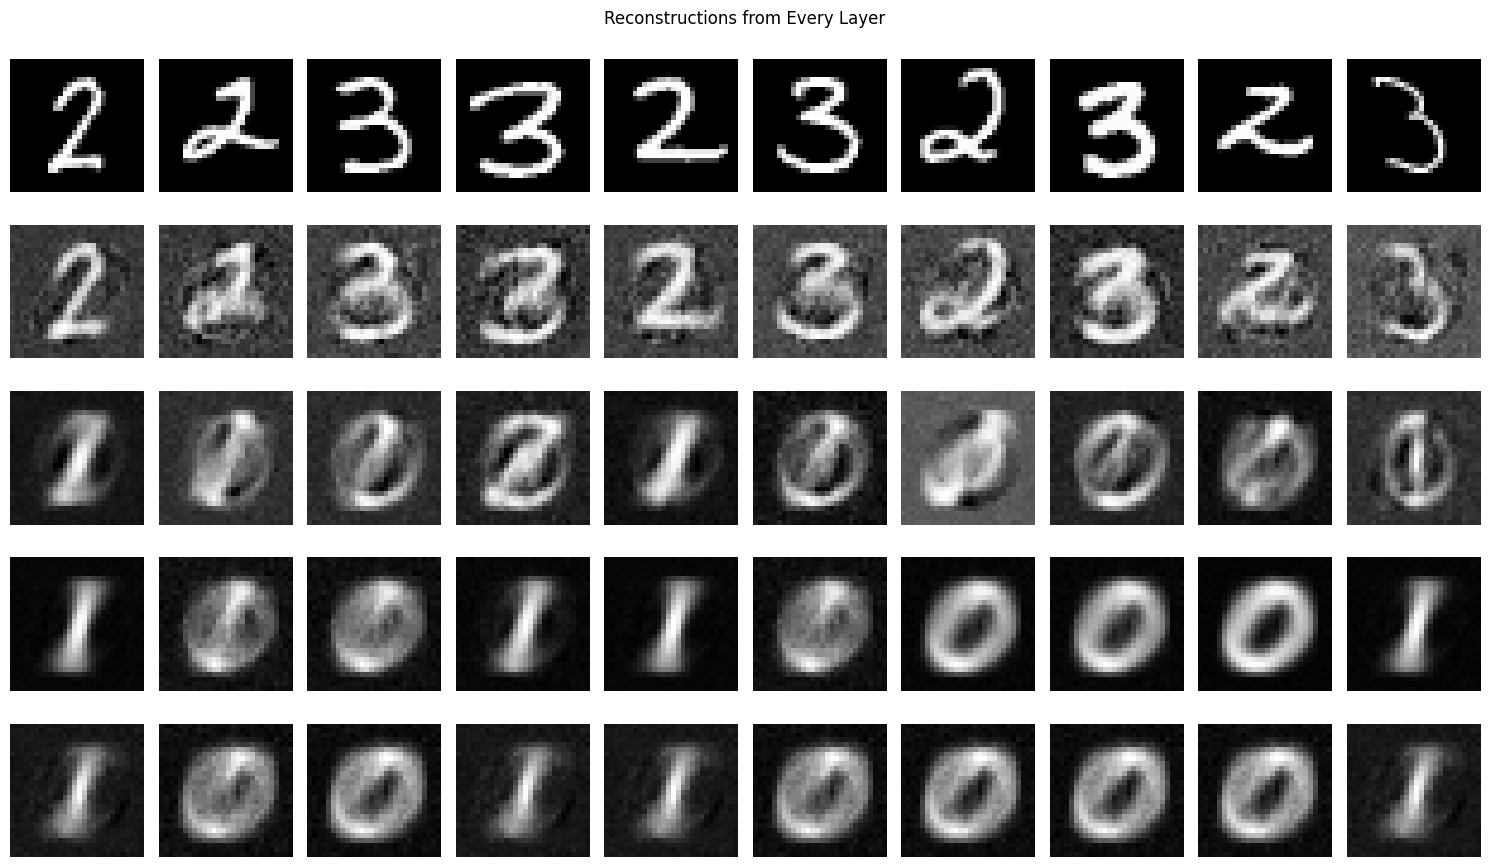

In [13]:
x, activations, reconstructions = visualize_reconstructions_general(
    model=model,
    dataset=tasks_dataloaders[1][0],   # DataLoader
    sm=True,
    device=model.device,
    n_samples=10,
    save=False,
    dir="plots/",
    filename="reconstructions.png"
)

In [36]:
#layer = model.layers[0]
layer = model.feedback_layers[0]

#W = torch.linalg.pinv(layer.weights).t().detach().cpu()  # shape (out_dim, in_dim)
W = layer.weights.t().detach().cpu()
print(W.shape)
n_rows = 8
n_cols = 8
n_units = min(n_rows * n_cols, W.shape[0])
img_size = int(W.shape[1] ** 0.5)  # assume square input, e.g. 28x28 for MNIST

plt.figure(figsize=(1.5 * n_cols, 1.5 * n_rows))
for i in range(n_units):
    rf = W[i].view(img_size, img_size)

    plt.subplot(n_rows, n_cols, i + 1)
    plt.imshow(rf, cmap="gray")
    plt.axis("off")

plt.suptitle(f"Receptive Fields - Layer {0}", fontsize=14)
plt.tight_layout()
plt.show()

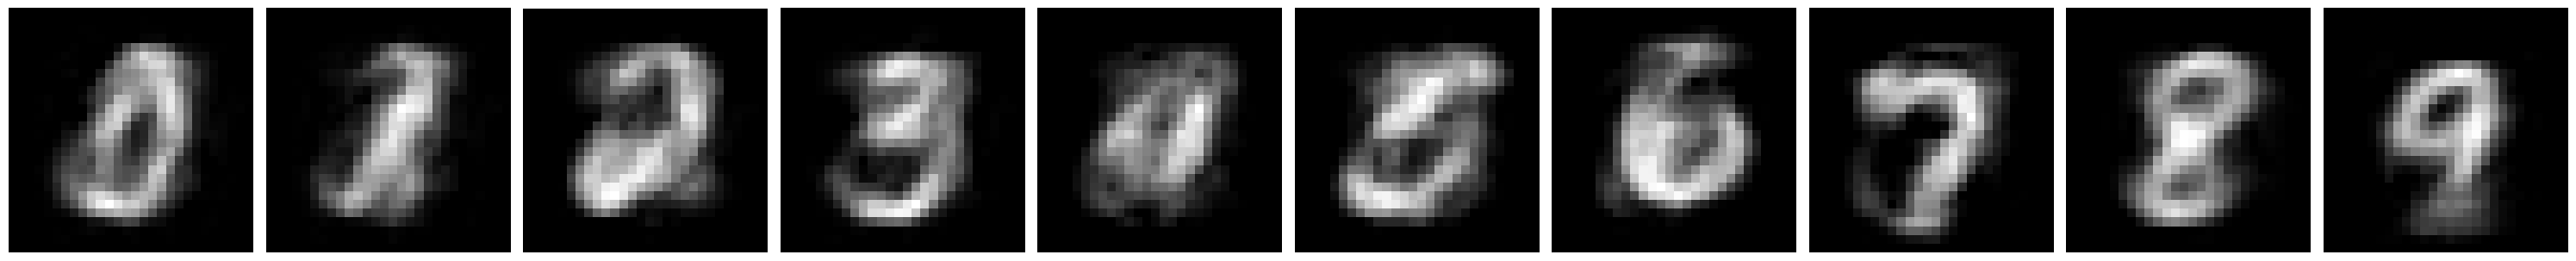

In [14]:
act = torch.eye(10, device="cuda")

for i in range(4):
    if i!=3:
        act = model.layers[-(i+2)].activation_fn(model.feedback_layers[-(i+1)](act))
    else:
        act = torch.clamp((model.feedback_layers[-(i+1)](act)), -0.4242, 2.8215)

fig, axes = plt.subplots(1, 10, figsize=(30, 4))

for i in range(10):
    axes[i].imshow(
        act[i].reshape(28, 28).detach().cpu().numpy(),
        cmap="gray"
    )
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [11]:
print(model.feedback_layers[-1].weights.t())
for i in range(10):
    print(torch.abs(model.feedback_layers[-1].weights.t()[i]).mean())

tensor([[-0.2869, -0.2921,  0.2494,  ...,  0.2848,  0.2440,  0.2634],
        [-0.2984, -0.2320,  0.2972,  ..., -0.2978,  0.2672, -0.2497],
        [-0.0316,  0.0087,  0.0609,  ..., -0.0272, -0.0156,  0.0339],
        ...,
        [ 0.0232, -0.0077,  0.0353,  ..., -0.0473,  0.0420,  0.0129],
        [-0.0070,  0.0569,  0.0170,  ...,  0.0112, -0.0398, -0.0568],
        [ 0.0228,  0.0617, -0.0588,  ...,  0.0364, -0.0410, -0.0191]],
       device='cuda:0', grad_fn=<TBackward0>)
tensor(0.2737, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.2716, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.0346, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.0350, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.0351, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.0362, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.0366, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.0338, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(0.0345, device='cuda:0', grad_fn=<MeanBackward0>)
tensor(